What is feature         
In Machine Learning         
Our Input Column and Varible is Features                   
And Our Ouptput Column and Varible is Target            
By Using Features We Predict Target .
Example : Given features Predict tart           
- In Business : sales data on social media instagram,facebook ,youtube precit sales
- In Acadmics : Given student cgpa and iq data predict package


What is feature Selection           
In the given features we extract the most important features for predication        
Example : If we have Total 10 column then we use the most important 4 columns for predication

Why do feature Selction         
Their are mainly 3 reasons
1. Curse of Dimensinity
2. Compuational Complexity
3. Interperatability 


What is Curse of Dimensinity?       
Dimensanity comes from the word dimension = number of column (varibles)  features in a system .
if you have a large number of features in a given machine learning model then it is like a curse (it is a bad thing )           
it says by using certain number of features you get optimum results     
if you add more number of features then your results is bad 


Today We use the famous Dataset : Human Activity Recognition With Smartphones           
Recording of 230 study participats Performing activites of Daily living         
researchers take 30 participants and unki kamar ma smarpt watch  band diya ha  fir unka unki ghar ki daily activities karna ho bola             
Example 
1. Walking
2. Walking upstaris and Downstair
3. Sitting
4. Standing
5. Laying           
and constanly the sensors accelrometer,gayrescope and various other sensor and measuring instruemnt             
and unki sensor ki reading ko note kar rahya ha 
The whole idea is hum un reading ko dekar kar samjana chata ha ki jo user ha ki vo abhi konsi position ma ha activity kar raha ha . kiya wo Walking  kiya vo chala raha ha ? kiya vo so raha ha ? kiya vo sidhi chal raha ha ? kiya wo bada ha ?        
and Then smartphones and smartwatches ya data ki reading la kar track kar sakta ha  ki aap jo movement kar raha ho vo kis type ka movement ha ?
Now apka smartphones kesa bata deta ki aap chal raha ho so raha ho ?
kyuki behind the sceeens machine learning is working  vo constanly apka sensor ka data ka uta raha ha  aor is tara ka classification model ma daal raha ha aor apka classification model give you the results       
isma sabsa challenging thing ha ya high dimensional data isma 563 columns aor 7000  rows ha lagbag  


In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\sumit\My_code_files\Data Science codes\week 26- Feature Selection\Data\train.csv').drop(columns='subject')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


In [3]:
print(df.columns.to_frame())

                                                                         0
tBodyAcc-mean()-X                                        tBodyAcc-mean()-X
tBodyAcc-mean()-Y                                        tBodyAcc-mean()-Y
tBodyAcc-mean()-Z                                        tBodyAcc-mean()-Z
tBodyAcc-std()-X                                          tBodyAcc-std()-X
tBodyAcc-std()-Y                                          tBodyAcc-std()-Y
...                                                                    ...
angle(tBodyGyroJerkMean,gravityMean)  angle(tBodyGyroJerkMean,gravityMean)
angle(X,gravityMean)                                  angle(X,gravityMean)
angle(Y,gravityMean)                                  angle(Y,gravityMean)
angle(Z,gravityMean)                                  angle(Z,gravityMean)
Activity                                                          Activity

[562 rows x 1 columns]


Overview of features
- All are numerical 
- All are normalised and scaled between 0 and 1
- senors sa data liya column and target column is activity 
- the instruemnt use in it and their stastical measure

In [4]:
# instruemnt use and their statistical measure 
df.columns.str.split('-').str.get(0).value_counts()

fBodyGyro                               79
fBodyAcc                                79
fBodyAccJerk                            79
tGravityAcc                             40
tBodyAcc                                40
tBodyGyroJerk                           40
tBodyGyro                               40
tBodyAccJerk                            40
tBodyAccMag                             13
fBodyAccMag                             13
fBodyBodyGyroJerkMag                    13
tGravityAccMag                          13
fBodyBodyAccJerkMag                     13
fBodyBodyGyroMag                        13
tBodyGyroJerkMag                        13
tBodyGyroMag                            13
tBodyAccJerkMag                         13
angle(tBodyAccMean,gravity)              1
angle(tBodyAccJerkMean),gravityMean)     1
angle(tBodyGyroMean,gravityMean)         1
angle(tBodyGyroJerkMean,gravityMean)     1
angle(X,gravityMean)                     1
angle(Y,gravityMean)                     1
angle(Z,gra

In [5]:
df.shape

(7352, 562)

In [6]:
df['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

These are the list of Classes ,label ,Activity column so we want to classify.           
so this is multiclass problem 


In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# separate Feature and Target
X = df.drop('Activity',axis=1)
y = df['Activity']

# Encode target labels
our_label_encoder = LabelEncoder()
y = our_label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Jab bhi aap feature selection karo tho aap apna data ko train test split karo . ek concept hota ha Data leakage ka . ki hamra testing data ko pata nahi chalna chaya about the testing data .           
fir aap action after report deko ga ki feature selection sa model ki performance imporve hui ki nahi 

In [8]:
print(X_train.shape)
print(X_test.shape)

(5881, 561)
(1471, 561)


## Applying Logistic Regression

In [9]:
# Initialize and train logistic regression model
logistic_regression_model = LogisticRegression(max_iter=1000)

logistic_regression_model.fit(X_train,y_train)

# Make predicaiton on the test set
y_pred = logistic_regression_model.predict(X_test)

# Calucate and print the accuracy score
print('Test accuracy :',accuracy_score(y_test,y_pred))

Test accuracy : 0.9809653297076818


Our challengae goal : Out of 562 column  apply filter feature selction then we choose the 100 column . model performance remains same

## 1. Duplicate features

In [10]:
# count every column how many times it appears
df.columns.value_counts().unique()

array([1], dtype=int64)

In [11]:
X_train.columns.value_counts

<bound method IndexOpsMixin.value_counts of Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyBodyGyroJerkMag-skewness()',
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)'],
      dtype='object', length=561)>

Meaning har ek column sirf dataframe ha ek hi baar aa raha ha

In [12]:
def get_duplicate_columns(df:pd.DataFrame ) -> pd.DataFrame:
    
    duplicate_columns = {}
    seen_columns = {}
    
    for column in df.columns:
        current_column = df[column]
        
    # Convert column data to bytes
        try:
            current_column_hash = current_column.values.tobytes()
        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_columns:
            if seen_columns[current_column_hash] in duplicate_columns:
                duplicate_columns[seen_columns[current_column_hash]].append(column)
            else:
                duplicate_columns[seen_columns[current_column_hash]] = [column]
        else:
            seen_columns[current_column_hash] = column

    return duplicate_columns
    
duplicate_col = get_duplicate_columns(df=X_train)
duplicate_col

{'tBodyAccMag-mean()': ['tBodyAccMag-sma()',
  'tGravityAccMag-mean()',
  'tGravityAccMag-sma()'],
 'tBodyAccMag-std()': ['tGravityAccMag-std()'],
 'tBodyAccMag-mad()': ['tGravityAccMag-mad()'],
 'tBodyAccMag-max()': ['tGravityAccMag-max()'],
 'tBodyAccMag-min()': ['tGravityAccMag-min()'],
 'tBodyAccMag-energy()': ['tGravityAccMag-energy()'],
 'tBodyAccMag-iqr()': ['tGravityAccMag-iqr()'],
 'tBodyAccMag-entropy()': ['tGravityAccMag-entropy()'],
 'tBodyAccMag-arCoeff()1': ['tGravityAccMag-arCoeff()1'],
 'tBodyAccMag-arCoeff()2': ['tGravityAccMag-arCoeff()2'],
 'tBodyAccMag-arCoeff()3': ['tGravityAccMag-arCoeff()3'],
 'tBodyAccMag-arCoeff()4': ['tGravityAccMag-arCoeff()4'],
 'tBodyAccJerkMag-mean()': ['tBodyAccJerkMag-sma()'],
 'tBodyGyroMag-mean()': ['tBodyGyroMag-sma()'],
 'tBodyGyroJerkMag-mean()': ['tBodyGyroJerkMag-sma()'],
 'fBodyAccMag-mean()': ['fBodyAccMag-sma()'],
 'fBodyBodyAccJerkMag-mean()': ['fBodyBodyAccJerkMag-sma()'],
 'fBodyBodyGyroMag-mean()': ['fBodyBodyGyroMag-sma()'

In [13]:
# now lets check it 
# ek hamra column ha aor 3 columns uska duplicated ha 
X_train[['tBodyAccMag-mean()', 'tBodyAccMag-sma()','tGravityAccMag-mean()','tGravityAccMag-sma()']]

,tBodyAccMag-mean(),tBodyAccMag-sma(),tGravityAccMag-mean(),tGravityAccMag-sma()
57,-0.997420,-0.997420,-0.997420,-0.997420
4154,-0.133797,-0.133797,-0.133797,-0.133797
6945,0.130528,0.130528,0.130528,0.130528
527,-0.955222,-0.955222,-0.955222,-0.955222
4196,-0.992499,-0.992499,-0.992499,-0.992499
...,...,...,...,...
5191,-0.372758,-0.372758,-0.372758,-0.372758
5226,-0.256033,-0.256033,-0.256033,-0.256033
5390,-0.434138,-0.434138,-0.434138,-0.434138
860,-0.983969,-0.983969,-0.983969,-0.983969


Now ya muja jo dictionary mila ha usma sa i keep the keys and delete  valuees column in the dataset

In [14]:
for one_list in duplicate_col.values():
    X_train.drop(columns= one_list,inplace=True)
    X_test.drop(columns= one_list,inplace=True)


In [15]:
print(X_train.shape)
print(X_test.shape)

(5881, 540)
(1471, 540)


Tho hamra pass 562 sa 540 dimension bacha                           
meaning 21 duplicate column tha 

## 2. Varience Threshold

First normalise your data .         
So our data is normalised and now set a varience threshold value between 0.1 to 0.01

In [16]:
from sklearn.feature_selection import VarianceThreshold
select_object = VarianceThreshold(threshold=0.05)

In [17]:
select_object.fit(X_train)

VarianceThreshold(threshold=0.05)

In [18]:
# now see the column jinka feature threshold sa kam ha
select_object.get_support()

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False,  True,
        True,  True, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True, False,
        True,  True,  True,  True,  True,  True,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True,  True,
        True,  True,  True, False, False, False,  True,  True,  True,
        True,  True,

tho ya 540 column ha .          
False ka matlab ha varience threshold sa nicha ha           
True ka matlab ha varience threshold sa nicha ha

In [19]:
# How many columns jinka varience threshold sa jada 
# total of it
sum(select_object.get_support())

349

tho 349 columns varience threshold ka upar ha baki ka columns varience threshold ka nicha ha                    


In [20]:
# Now we want to see the 349 columns 
# use numpy boolean indexing concpet 
X_train.columns[select_object.get_support()]

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z',
       'tBodyAcc-min()-X',
       ...
       'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyBodyGyroJerkMag-skewness()',
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)'],
      dtype='object', length=349)

In [21]:
# now hum delete karta ja raha ha jin column ka value varience threshold sa nicha ha 
select_object.transform(X_train)

array([[-0.9944254 , -0.99487263, -0.99488582, ...,  0.39888109,
        -0.54671715, -0.43119994],
       [-0.32633148,  0.0696628 , -0.22432128, ..., -0.47401293,
         0.38316244,  0.23896924],
       [-0.02621997, -0.03216306,  0.39310852, ..., -0.81900124,
         0.22154911, -0.00357091],
       ...,
       [-0.62719763, -0.21656585, -0.42476369, ..., -0.85651241,
         0.18354749, -0.03493857],
       [-0.9948248 , -0.98531367, -0.96585729, ..., -0.83969327,
         0.08138803, -0.09827024],
       [-0.36865452, -0.14263084, -0.15125003, ..., -0.86809289,
         0.18822594,  0.00274405]])

In [22]:
var_threshold_columns = X_train.columns[select_object.get_support()]

In [23]:
# assign it to new array
X_train = select_object.transform(X_train)
X_test = select_object.transform(X_test)

# change the names
X_train = pd.DataFrame(X_train, columns = var_threshold_columns)
X_test = pd.DataFrame(X_test, columns = var_threshold_columns)

In [24]:
print(X_train.shape)
print(X_test.shape)

(5881, 349)
(1471, 349)


In [25]:
# now see your data
X_train.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.994425,-0.994873,-0.994886,-0.994939,-0.993994,-0.995450,-0.938974,-0.577031,-0.813863,0.846922,...,0.394506,-0.684497,-0.901888,0.751089,0.626432,0.263401,-0.646225,0.398881,-0.546717,-0.431200
1,-0.326331,0.069663,-0.224321,-0.343326,0.039623,-0.256327,-0.310961,0.085617,-0.411806,0.271334,...,0.052089,-0.131946,-0.591721,0.628099,-0.357089,-0.925512,0.110212,-0.474013,0.383162,0.238969
2,-0.026220,-0.032163,0.393109,-0.118256,-0.030279,0.432861,0.370607,-0.072309,0.200747,0.118277,...,-0.038923,-0.643660,-0.935668,-0.182993,0.484857,-0.961034,0.147325,-0.819001,0.221549,-0.003571
3,-0.981092,-0.901124,-0.960423,-0.984417,-0.901405,-0.965788,-0.922291,-0.524676,-0.807362,0.825370,...,-0.145084,-0.326860,-0.645937,0.205896,-0.168239,-0.197557,0.328892,-0.744428,0.274256,0.031246
4,-0.997380,-0.983893,-0.984482,-0.997331,-0.985196,-0.983768,-0.942062,-0.564033,-0.810993,0.853330,...,0.096524,-0.113724,-0.445144,-0.267371,-0.304399,-0.081555,0.110146,-0.615329,0.322236,0.161577


you can not apply variance threshold blindly            
aap ko kuch cheeza dhyan ma rakni hoga

## 3. Correlation
We apply the bructe force approach har ek feature ka dursa feature ka sath linear realtionship nikala ga                
                 yadi vo 0.95 sa bada hoga tho hum usa drop kar dega 

In [26]:
# find multicollinatiy between the features 
X_train.corr()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
tBodyAcc-std()-X,1.000000,0.927247,0.850268,0.998631,0.920936,0.845200,0.981284,0.893743,0.843918,-0.966714,...,-0.061190,0.152159,0.118286,-0.042353,-0.027089,0.023914,-0.035176,-0.374114,0.472605,0.393209
tBodyAcc-std()-Y,0.927247,1.000000,0.895065,0.922627,0.997384,0.894128,0.917831,0.953852,0.882782,-0.937472,...,-0.103492,0.210313,0.179834,-0.023759,-0.012484,-0.002241,-0.028881,-0.383095,0.524945,0.432180
tBodyAcc-std()-Z,0.850268,0.895065,1.000000,0.842986,0.890973,0.997414,0.852711,0.864716,0.936311,-0.861033,...,-0.095347,0.157032,0.124579,-0.009647,-0.020843,-0.010535,-0.016002,-0.344114,0.475241,0.480824
tBodyAcc-mad()-X,0.998631,0.922627,0.842986,1.000000,0.916201,0.838010,0.973704,0.888702,0.838024,-0.962447,...,-0.055098,0.153494,0.120750,-0.049949,-0.026887,0.024098,-0.035629,-0.370629,0.467965,0.389139
tBodyAcc-mad()-Y,0.920936,0.997384,0.890973,0.916201,1.000000,0.890707,0.911283,0.950131,0.877793,-0.932521,...,-0.101235,0.205346,0.175966,-0.027747,-0.011823,-0.005865,-0.026679,-0.379578,0.526803,0.430548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"angle(tBodyGyroMean,gravityMean)",0.023914,-0.002241,-0.010535,0.024098,-0.005865,-0.014838,0.029230,-0.000207,-0.023622,-0.008700,...,-0.024274,0.031310,0.021829,-0.006297,0.013870,1.000000,-0.104987,-0.009878,-0.006218,-0.011178
"angle(tBodyGyroJerkMean,gravityMean)",-0.035176,-0.028881,-0.016002,-0.035629,-0.026679,-0.016949,-0.038935,-0.013144,-0.011510,0.030630,...,-0.000472,-0.030566,-0.028829,-0.025656,0.030850,-0.104987,1.000000,0.027310,-0.009582,-0.009311
"angle(X,gravityMean)",-0.374114,-0.383095,-0.344114,-0.370629,-0.379578,-0.346350,-0.386159,-0.373556,-0.345776,0.365571,...,0.077000,-0.086273,-0.081381,0.012546,0.022038,-0.009878,0.027310,1.000000,-0.784098,-0.642642
"angle(Y,gravityMean)",0.472605,0.524945,0.475241,0.467965,0.526803,0.476498,0.482312,0.489971,0.462052,-0.471464,...,-0.093215,0.086150,0.078420,-0.003872,-0.005159,-0.006218,-0.009582,-0.784098,1.000000,0.596205


<Axes: >

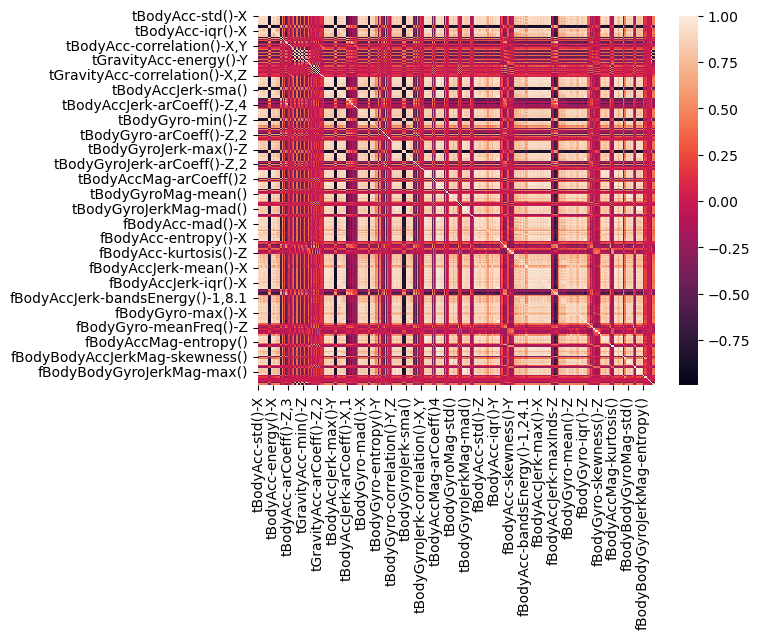

In [27]:
# Visualise it 
import seaborn as sns
sns.heatmap(X_train.corr())

In [28]:
import plotly.express as px
px.imshow(
    img =X_train.corr(),
    width = 800, height = 600
        )


In [29]:
# create a corelation matrix
correlation_matrix = X_train.corr()
# get the names of cols from correlation matrix
columns = correlation_matrix.columns

columns_to_drop = []

# loop overt the columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        # Access the cell of the Dataframe
        if correlation_matrix.loc[columns[i],columns[j]] > 0.95:
            columns_to_drop.append(columns[j])
            
print(len(columns_to_drop))

1508


Question : hamra pass tho 540 cols ha ya 1508 kesa aa gaya          
deko f1,f2 ka multiconiaty ha lakin f2 ka f1 ka sath bhi tho multicollianrity ha tho ya do par count ho gaya

In [30]:
len(set(columns_to_drop))

197

tho mera pass 197 columns ha jisma correaltion > 0.95 sa bada ha            
en 197 ko hum drop karna wala ha 

In [31]:
# permantley change it into set
columns_to_drop = set(columns_to_drop)

In [32]:
X_train.drop(columns = columns_to_drop, axis = 1, inplace=True)
X_test.drop(columns = columns_to_drop, axis = 1, inplace=True)

In [33]:
print(X_train.shape)
print(X_test.shape)

(5881, 152)
(1471, 152)


In [34]:
# now let see our dataframe
X_train.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,...,fBodyBodyGyroMag-skewness(),fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.994425,-0.994873,-0.994886,-0.813863,0.846922,0.691468,0.846423,-0.611174,-0.768785,-0.663066,...,0.043182,0.394506,-0.684497,0.751089,0.626432,0.263401,-0.646225,0.398881,-0.546717,-0.431200
1,-0.326331,0.069663,-0.224321,-0.411806,0.271334,0.039452,0.269204,0.403663,0.180054,0.176069,...,-0.225796,0.052089,-0.131946,0.628099,-0.357089,-0.925512,0.110212,-0.474013,0.383162,0.238969
2,-0.026220,-0.032163,0.393109,0.200747,0.118277,0.072295,0.245986,0.318557,0.135103,0.087680,...,-0.346388,-0.038923,-0.643660,-0.182993,0.484857,-0.961034,0.147325,-0.819001,0.221549,-0.003571
3,-0.981092,-0.901124,-0.960423,-0.807362,0.825370,0.642789,0.815368,-0.376515,-0.171730,-0.496816,...,0.197311,-0.145084,-0.326860,0.205896,-0.168239,-0.197557,0.328892,-0.744428,0.274256,0.031246
4,-0.997380,-0.983893,-0.984482,-0.810993,0.853330,0.687431,0.844895,-0.652548,-0.678458,-0.486837,...,0.310607,0.096524,-0.113724,-0.267371,-0.304399,-0.081555,0.110146,-0.615329,0.322236,0.161577


deko humara paas f1,f2 column ha                
aap kisko drop kara f1 ya f2 aap iska relation deko f1-> y ka sath or f2 -> y ka sath                   
fir jiska strong relation uska rakaga aor jiska weak ha usko drop kar dega              

aap chaho tho similar group bhi bana sakta ha same correlation ka fir us group ma sa sabsa important feature nikalana           
ya hum sika ga jab hum embeed methods padaga 

Summary                 
- har ek input column ka dursa input column ka sath correaltion nikala 
- fir ja par bhi ek pair ka bithch  linear correaltion > 0.95 sa bada ha 
- un dono ma sa ek ko randomly drop kar diya 
- baki mera pass 152 columns ha 

## 4. ANOVA
Their are two types of one way anova usecase
1. numerical - Categorgical
2. Numerical - Numerical             
We use the One way anova Numerical - Cateorgical             
In Which $f_1,f_2,f_3 ....f_{152} \quad Y$ We find the linear relationship between feature and target.          
We take the one feature and see the see the realtionship with target            
f1 -> y             
f2 -> y             
...            
fn -> y

Aap Question puch raha ho ki ya linear relationship strong ha ki nahi 

In [ ]:
from sklearn.feature_selection import f_classif # f_score ho import kiya
from sklearn.feature_selection import SelectKBest # sara columns par lagay ha

select_object = SelectKBest(f_classif,k=100).fit(X_train,y_train)
# k = 100 ka matlab ha 152 ma sa muja 100 best column nikal kar bataho
# display selected feature names
X_train.columns[select_object.get_support()] # this are the best 100 columns according to the anova

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y',
       'tBodyAcc-min()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y',
       'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1',
       'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3',
       'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Z,1',
       'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-Y,Z',
       'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z',
       'tGravityAcc-sma()', 'tGravityAcc-energy()-Y', 'tGravityAcc-energy()-Z',
       'tGravityAcc-entropy()-X', 'tGravityAcc-entropy()-Y',
       'tGravityAcc-arCoeff()-Y,1', 'tGravityAcc-arCoeff()-Y,2',
       'tGravityAcc-arCoeff()-Z,1', 'tGravityAcc-arCoeff()-Z,2',
       'tGravityAcc-correlation()-Y,Z', 'tBodyAccJerk-std()-Z',
       'tBodyAccJerk-min()-X', 'tBodyAccJerk-min()-Y', 'tBodyAccJerk-min()-Z',
       'tBodyAccJerk-entropy()-X', 'tBodyAccJerk-arCoeff

Now 152 sa top 100 columns ko la raha ha 

In [40]:
anova_columns = X_train.columns[select_object.get_support()]

In [43]:
# assign it to new array
X_train = select_object.transform(X_train)
X_test = select_object.transform(X_test)

# change the names
X_train = pd.DataFrame(X_train, columns = anova_columns)
X_test = pd.DataFrame(X_test, columns = anova_columns)

In [44]:
X_train.head()

,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,...,fBodyGyro-meanFreq()-Z,"fBodyGyro-bandsEnergy()-1,8.1",fBodyAccMag-maxInds,fBodyBodyAccJerkMag-min(),fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyGyroMag-meanFreq(),"angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,-0.994425,-0.994873,-0.994886,-0.813863,0.846922,0.691468,0.846423,-0.611174,-0.768785,-0.663066,...,-0.158283,-0.999962,0.172414,-0.986305,0.132640,-0.690000,-0.024257,0.398881,-0.546717,-0.431200
1,-0.326331,0.069663,-0.224321,-0.411806,0.271334,0.039452,0.269204,0.403663,0.180054,0.176069,...,-0.315738,-0.898022,-0.517241,-0.718822,0.144767,-0.316666,0.191186,-0.474013,0.383162,0.238969
2,-0.026220,-0.032163,0.393109,0.200747,0.118277,0.072295,0.245986,0.318557,0.135103,0.087680,...,-0.071045,0.192158,-0.793103,-0.290424,-0.088077,-0.270995,-0.431985,-0.819001,0.221549,-0.003571
3,-0.981092,-0.901124,-0.960423,-0.807362,0.825370,0.642789,0.815368,-0.376515,-0.171730,-0.496816,...,-0.629423,-0.996263,-0.931034,-0.997886,-0.027783,-0.651181,-0.567748,-0.744428,0.274256,0.031246
4,-0.997380,-0.983893,-0.984482,-0.810993,0.853330,0.687431,0.844895,-0.652548,-0.678458,-0.486837,...,0.261846,-0.999927,-1.000000,-0.988139,0.668020,-0.598248,-0.257360,-0.615329,0.322236,0.161577


 Moment of truth 

In [53]:
print(X_train.shape)
print(X_test.shape)

(5881, 100)
(1471, 100)


Now apply the logistic regression again on our 100 feaatures and see it 

In [54]:
# Initialize and train logistic regression model
logistic_regression_model = LogisticRegression(max_iter=1000)

logistic_regression_model.fit(X_train,y_train)

# Make predicaiton on the test set
y_pred = logistic_regression_model.predict(X_test)

# Calucate and print the accuracy score
print('Test accuracy :',accuracy_score(y_test,y_pred))

Test accuracy : 0.9694085656016316


Tho phala accuracy = 98 thi now after fixed feature selction we have 100 columns accruacy is 100 columns 

## 5. Chi-Square
Used when both input and ouptut both are cateogrical 

In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
# import the titanic dataset only categorical variables 
titanic_path = r'C:\Users\sumit\My_code_files\Data Science codes\week 12-Data Analysis Process Continued\train.csv'
titanic_df = pd.read_csv(titanic_path, usecols=[ 'Pclass', 'Sex' , 'SibSp','Parch', 'Embarked','Survived'])

titanic_df

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,male,1,0,S
1,1,1,female,1,0,C
2,1,3,female,0,0,S
3,1,1,female,1,0,S
4,0,3,male,0,0,S
...,...,...,...,...,...,...
886,0,2,male,0,0,S
887,1,1,female,0,0,S
888,0,3,female,1,2,S
889,1,1,male,0,0,C


Example Question pucha gaya         
Kiya Sex and Survived column ka bitch ma koi relationship ha ki nahi            
matlab survival predict karna ka liya gender ki information ek kam ayi gi ki nahi kiya vo ek important feature ha ki nahi               
you use the chi-square test .       
- make a contegnacy table between categorical table simple frequency count kra raho ho

In [7]:
contengency_table = pd.crosstab(titanic_df['Survived'],titanic_df['Sex'])
contengency_table

Sex,female,male
Survived,,
0,81,468
1,233,109


In [41]:
print(contengency_table.to_markdown(tablefmt = 'grid'))

+------------+----------+--------+
|   Survived |   female |   male |
+============+==========+========+
|          0 |       81 |    468 |
+------------+----------+--------+
|          1 |      233 |    109 |
+------------+----------+--------+


Interperations of it
1. female who died = 81
1. female who survived =  233
1. male who died = 468
1. male who survived =  109         
isko bolta ha observed value ya hum data ma mila experimental value real data 

Now we make a another table in which we have expected value  theortical value ideal data 


In [5]:
contengency_table = pd.crosstab(titanic_df['Survived'],titanic_df['Sex'],margins=True)
contengency_table

Sex,female,male,All
Survived,,,
0,81,468,549
1,233,109,342
All,314,577,891


In [35]:
print(contengency_table.to_markdown(tablefmt = 'grid'))

+------------+----------+--------+-------+
| Survived   |   female |   male |   All |
+============+==========+========+=======+
| 0          |       81 |    468 |   549 |
+------------+----------+--------+-------+
| 1          |      233 |    109 |   342 |
+------------+----------+--------+-------+
| All        |      314 |    577 |   891 |
+------------+----------+--------+-------+


+------------+----------+--------+-------+
| Survived   |   female |   male |   All |
+============+==========+========+=======+
| 0          |       81 |    468 |   549 |
+------------+----------+--------+-------+
| 1          |      233 |    109 |   342 |
+------------+----------+--------+-------+
| All        |      314 |    577 |   891 |
+------------+----------+--------+-------+

Har ek value ka liya 
$\frac{Row-total * Column-total}{total}$                
$\frac{549 * 314}{891} =193$

In [ ]:
# females who died 
549 * 314

172386

In [17]:
172386/891

193.4747474747475

In [ ]:
# males who died 
(549 * 577)/891

355.52525252525254

In [21]:
# female who survived
(314* 342)/891

120.52525252525253

In [ ]:
# male who survived
(342 * 577)/891

221.4747474747475

Expected  value

+------------+----------+--------+
|   Survived |   female |   male |
+============+==========+========+
|          0 |    193   |    355 |
+------------+----------+--------+
|          1 |    120   |    221 |
+------------+----------+--------+

Observed Value

Ab muja en dono ka bitch ka difference study karna ha           
yadi observed or expected ka bitch ma crazy number difference ha            
Meaning en dono varibles sex and survived ka bitch ma relationship ha 

Chi square hypotehis test :             
Null : No relationship between observed and expected values
Alternative : Their is relationship observed and expected values 

$ \text{chi-sqaure statistics} = \frac{(\text{observed} - \text{expected })^2} {\text{expected }}$

fir p-value calucate karta ho

In [12]:
from scipy.stats import chi2_contingency
chi2_contingency(contengency_table)


Chi2ContingencyResult(statistic=260.71702016732104, pvalue=1.1973570627755645e-58, dof=1, expected_freq=array([[193.47474747, 355.52525253],
       [120.52525253, 221.47474747]]))

In [14]:
score = []

for feature in titanic_df.columns[:-1]:
    
    # create contigency table
    ct = pd.crosstab(titanic_df['Survived'],titanic_df[feature])
    # chi_square test
    p_value = chi2_contingency(ct)[1]
    score.append(p_value)

In [20]:
pd.Series(score,index = titanic_df.columns[:-1]).sort_values(ascending=True)

Survived    7.352052e-195
Sex          1.197357e-58
Pclass       4.549252e-23
SibSp        1.558581e-06
Parch        9.703526e-05
dtype: float64

<Axes: >

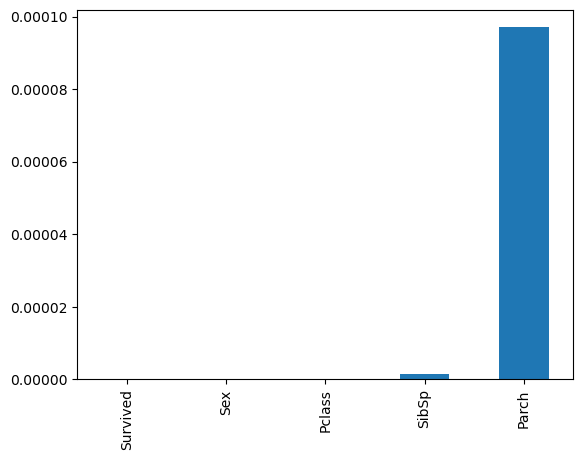

In [18]:
pd.Series(score,index = titanic_df.columns[:-1]).sort_values(ascending=True).plot(kind='bar')

Tho sabsa chota p-value  Survived Sex ,p_class Sib sip ,then pach ka 

Jitna big p-value utana kam important           
jitna small p-value utan jada important 

Tho top 3 categorical varible is  Sex ,p_class Sib sip

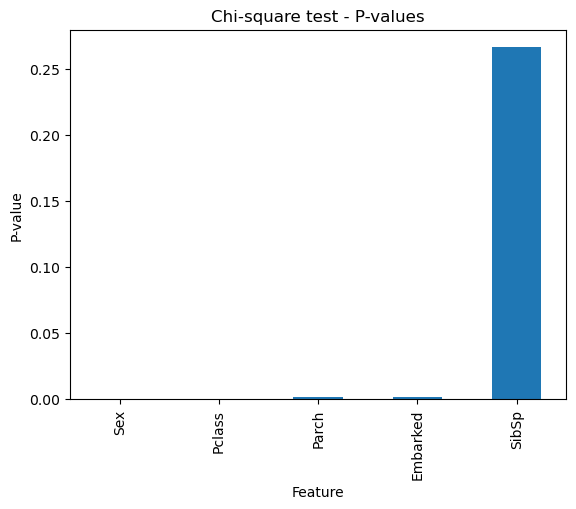

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

# assuming titanic is your DataFrame and 'Survived' is the target column

# Encode categorical variables
le = LabelEncoder()
titanic_encoded = titanic_df.apply(le.fit_transform)

X = titanic_encoded.drop('Survived', axis=1)
y = titanic_encoded['Survived']

# Calculate chi-squared stats
chi_scores = chi2(X, y)

# chi_scores[1] are the p-values of each feature.
p_values = pd.Series(chi_scores[1], index = X.columns)
p_values.sort_values(inplace = True)

# Plotting the p-values
p_values.plot.bar()

plt.title('Chi-square test - P-values')
plt.xlabel('Feature')
plt.ylabel('P-value')

plt.show()

## 6. Mutual information

In [2]:
import pandas as pd

data = {
    'A': ['a1', 'a2', 'a1', 'a1', 'a2', 'a1', 'a2', 'a2'],
    'B': ['b1', 'b2', 'b2', 'b1', 'b1', 'b2', 'b2', 'b1']
}

df = pd.DataFrame(data)
df

,A,B
0,a1,b1
1,a2,b2
2,a1,b2
3,a1,b1
4,a2,b1
5,a1,b2
6,a2,b2
7,a2,b1


In [ ]:
# calucate margianl probabilities
marginal_prob = pd.crosstab(df['A'], df['B'], margins=True, normalize='all')
marginal_prob

B,b1,b2,All
A,,,
a1,0.25,0.25,0.5
a2,0.25,0.25,0.5
All,0.50,0.50,1.0


In [4]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
import pandas as pd

# Load iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']

# Compute mutual information
mi = mutual_info_classif(X, y)

# Print mutual information
for i, mi_value in enumerate(mi):
    print(f"Feature {i}: Mutual Information = {mi_value}")

Feature 0: Mutual Information = 0.48768359030527497
Feature 1: Mutual Information = 0.22485372726522135
Feature 2: Mutual Information = 0.9986615954653069
Feature 3: Mutual Information = 0.9855303426165618


In [5]:
mi

array([0.48768359, 0.22485373, 0.9986616 , 0.98553034])

In [6]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']

# Create SelectKBest feature selector
selector = SelectKBest(mutual_info_classif, k=2)

# Fit and transform
X_new = selector.fit_transform(X, y)

# Get columns to keep and create new dataframe with those only
cols = selector.get_support(indices=True)

print(iris.feature_names)
print(cols)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[2 3]
